Técnicas de Inteligencia Artificial

_MU en Análisis y Visualización de Datos Masivos_

# Árboles de decisión para clasificación


## ¿Qué problema vamos a resolver?

Resolveremos un **problema de clasificación** utilizando el  algoritmos de aprendizaje supervisado **Árboles de decisión**. El problema específico que queremos resolver es **predecir si un pasajero sobrevirá al naufragio o no**. Es decir, predecir la probabilidad de que un pasajero pertenezca a la Clase 0 (NO sobrevive) y 1 (Sobrevive).


### Descripción de los datos

- **PassengerId** = identificador único de cada pasajero
- **Name** = nombre del pasajero
- **Sex** = factor, con niveles (masculino y femenino)
- **Age** = edad del pasajero
- **Pclass** = clase eb la que viajaba el pasajero
embarked = lugar en el que embarcó el pasajero
- **Ticket** = número de ticket del pasajero (na para la tripulación)
- **Fare** = precio del ticket (na para la tripulación, musicos,
empleados y otros)
- **SibSp** = número de hermanos/familiares
- **Cabin** = cabina que ocupa cada pasajero
- **Parch** = número de padres e hijos a bordo
- **Survived** = especifica si el pasajero sobrevivió al hundimiento

### Paso 1. Importamos las librerías y cargamos el dataset

In [1]:
# Importamos las librerías necesarias
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# Cargamos el dataset
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


###Paso 2: Describimos la estructura de los datos y sus principales estadísticas

In [3]:
# Leemos el dataset y vemos el número de variables que tiene
import io
data = pd.read_csv(io.BytesIO(uploaded['train.csv']), sep=',')
data.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
# Vemos el número de instancias que tiene el dataset
data.shape

(891, 12)

**1**. ¿Cuántas variables tiene el dataset?

**Respuesta:** Tiene 12 variables.

**2**. ¿Cuántas instancias tiene el dataset?

**Respuesta:** Tiene 891 instancias.

In [6]:
# Generamos estadísticas descriptivas  de los datos
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**3**. ¿Cómo están distribuidos los datos en términos generales?


**Respuesta:**
- Observamos que todas las variables tienen el mismo número de instancias, 891 a excepción de la variable Age que tiene 714 lo que nos da a entender que pueden existir valores faltantes.
- Vemo que por lo general las medias son razonables respecto a los valores minimos y maximos que adoptan las variables.
- Respecto a la variable PClass si observamos la distribución por cuartiles vemos que el 25% de las personas iban en primera y segunda clase, el 50% y el 75%  iban por debajo de 3 clase. De esto se deduce que la mayor parte de los viajeros viajaban en la clase 3 clase



In [7]:
# Vemos qué tipos de variables contiene el dataset y qué valores no contienen nulos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**4**. ¿Cuántas variables contínuas, enteras y texto tiene el dataset?

**Respuesta**: Hay 7 variables numéricas: 5 enteras int64 y 2 decimales float64. Hay 5 variables de tipo string (object).

In [8]:
# Visualizamos el total de valores nulos de cada variable del dataset
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**5**. ¿Existen valores nulos en el dataset? Indica en que variables se dan?

**Respuesta:** Existen valores nulos que se dan en las variables Age (177), Cabin (687) y Embarked (2)

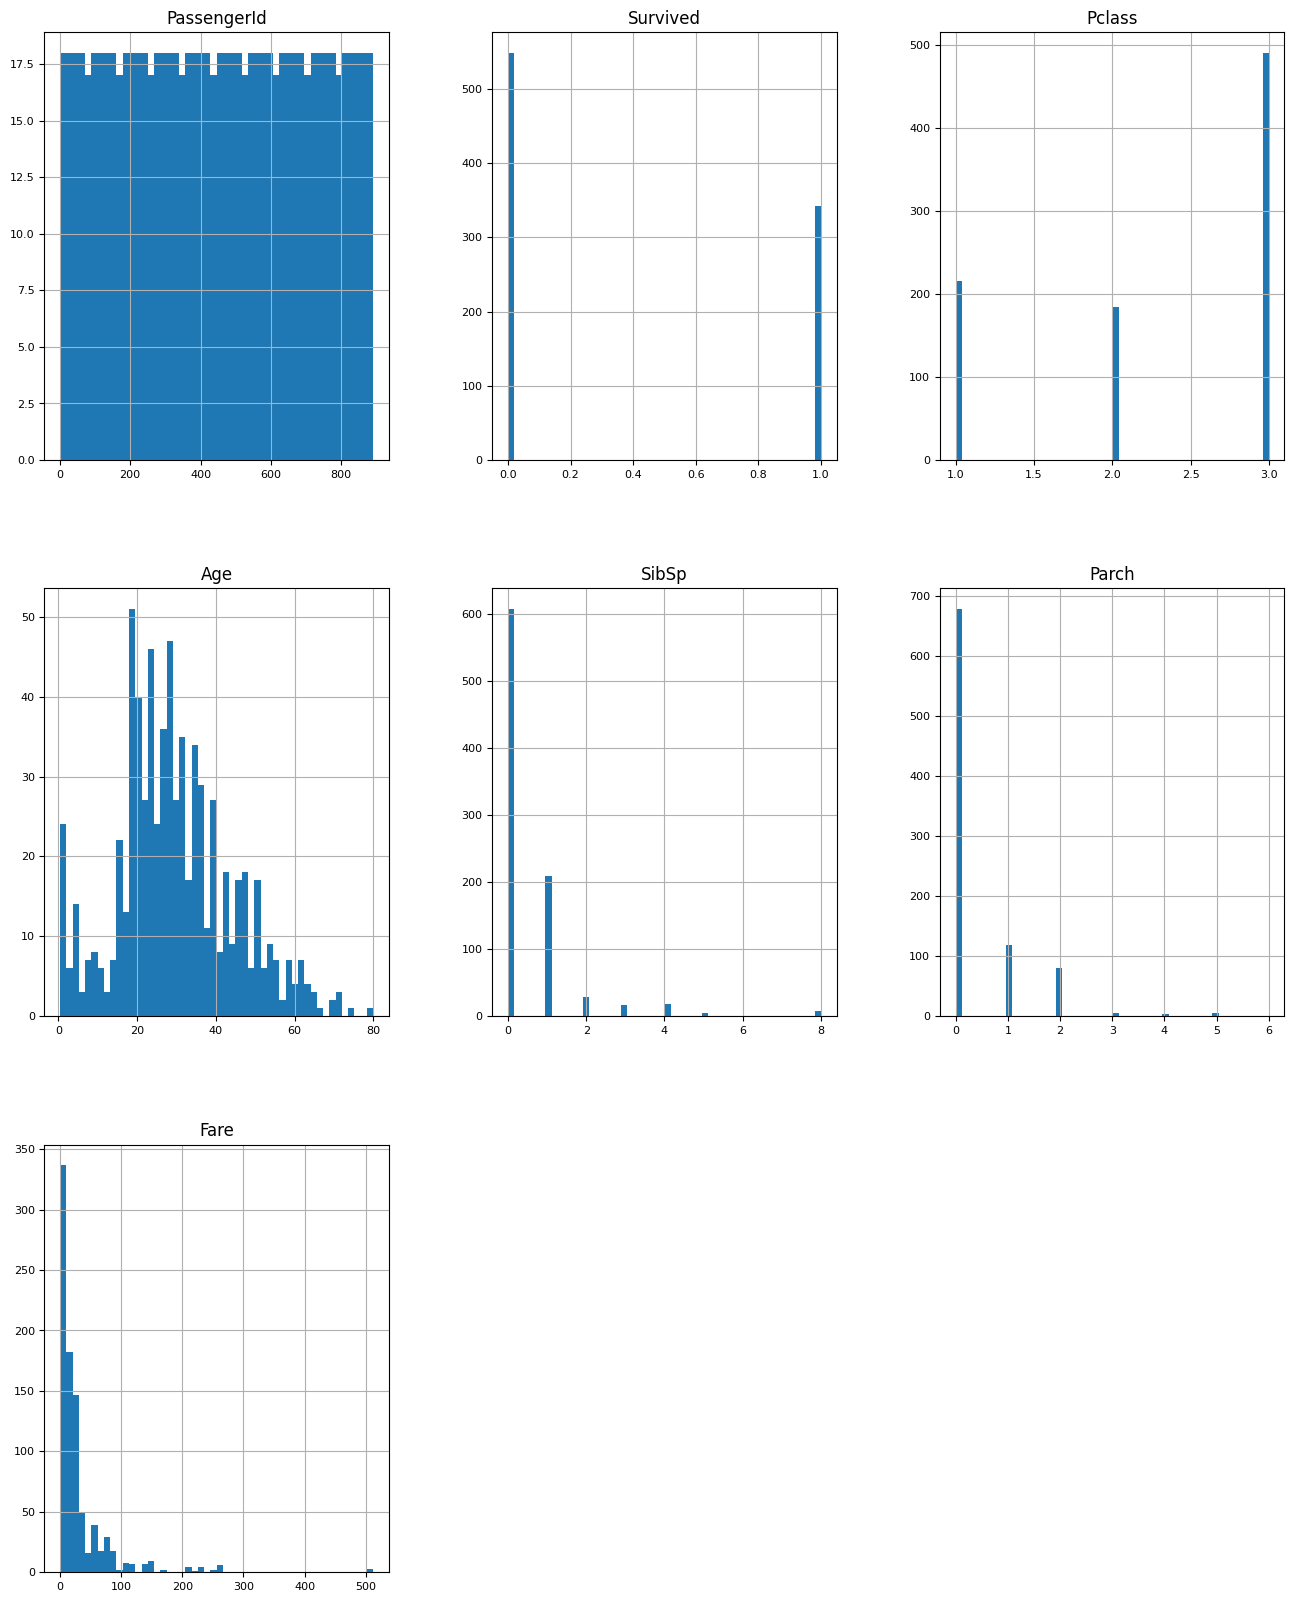

In [9]:
# 1.6 Dibujamos los histogramas de las variables numéricas para conocer su distribución
data.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

**6**. ¿Qué información nos aportan los histograma de cada variable?

**Respuesta**

In [ ]:
#Elegimos la variable Pclass para ver los distintos valores que adopta y saber si es categórica o no
print('Pclass: ',data['Pclass'].unique())

**7**. ¿Piensas que la variable Pclass es una variable categórica?

**Respuesta:** Sí,dado que adopta valores acotados a 1,2,3

[Text(0.5, 0, 'PassengerId'),
 Text(1.5, 0, 'Survived'),
 Text(2.5, 0, 'Pclass'),
 Text(3.5, 0, 'Age'),
 Text(4.5, 0, 'SibSp'),
 Text(5.5, 0, 'Parch'),
 Text(6.5, 0, 'Fare')]

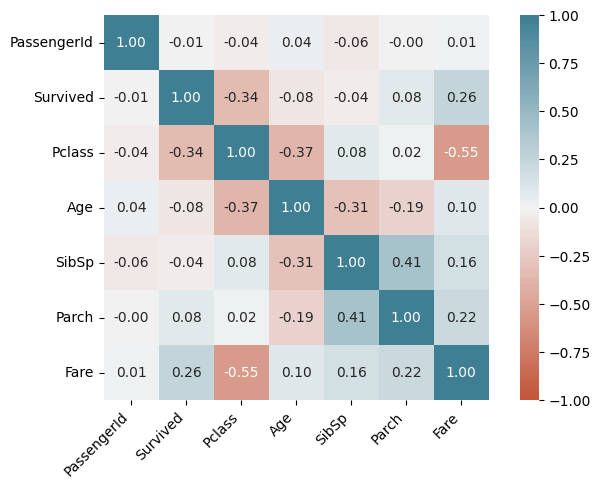

In [10]:
# Calculamos el coeficiente de correlación de Pearson
corr = data.corr(method ='pearson', numeric_only=True)

# Hacemos un headpmap con tamaño ampliado, cuadrado, divergencia con colores y con anotaciones de 2 decimales
plt.figure(figsize=(8,5))
ax = sns.heatmap(
 corr,
 vmin=-1, vmax=1, center=0,
 cmap=sns.diverging_palette(20, 220, n=200),
 square=True, annot=True, fmt=".2f"
)
# Rotamos las etiquetas del eje horizontal
ax.set_xticklabels(
 ax.get_xticklabels(),
 rotation=45,
 horizontalalignment='right'
)

**8**. ¿Qué información de valor para nuestro análisis nos proporciona la matriz de correlación? ¿Existe alguna variable altamente correlacionada con la variable que queremos predecir?

**Respuesta**: No se observa ninguna variable altamente correlacionada por lo que es difícil identificar en este momento una variable que influya significativamente en la variable objetivo o variable a predecir Survived.

### Paso 3: Visualizaciones de variables

**¿Cuántos pasajeros sobrevivieron?**

/tmp/ipykernel_2290/4049117570.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived',data=data, palette="hls")


<Axes: xlabel='Survived', ylabel='count'>

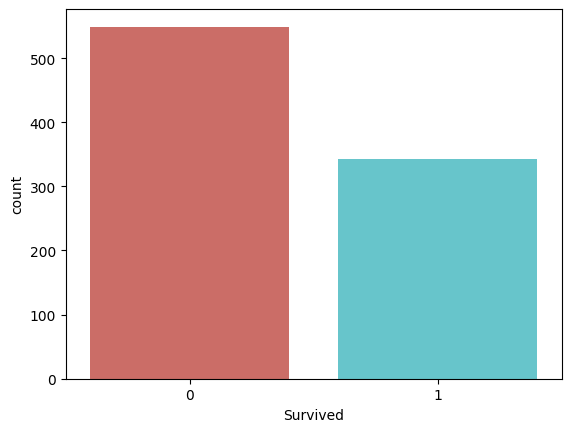

In [11]:
sns.countplot(x='Survived',data=data, palette="hls")

**¿Cuántos hombres y mujeres había entre los pasajeros?**

/tmp/ipykernel_2290/981361052.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex',data=data, palette="husl")


<Axes: xlabel='Sex', ylabel='count'>

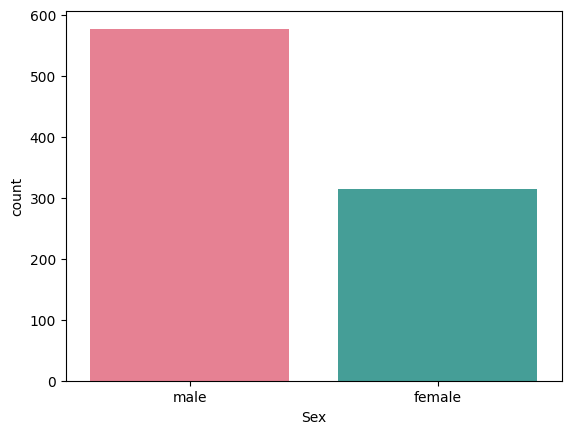

In [12]:
sns.countplot(x='Sex',data=data, palette="husl")

**¿Cuántos pasajeros viajaban en cada clase?**

/tmp/ipykernel_2290/2328533062.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass',data=data, palette="muted")


<Axes: xlabel='Pclass', ylabel='count'>

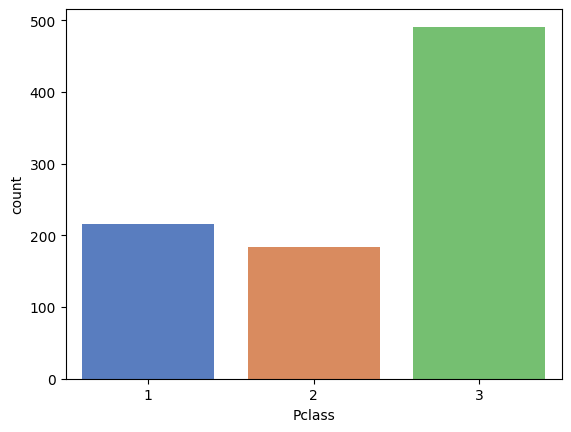

In [13]:
sns.countplot(x='Pclass',data=data, palette="muted")

**Supervivientes en función del género del pasajero en número total y en porcentaje %**

In [14]:
pd.crosstab(data.Sex,data.Survived).style.background_gradient(cmap='summer_r')

Survived,0,1
Sex,,
female,81,233
male,468,109


In [15]:
pd.crosstab(data.Sex,data.Survived, normalize='index').style.background_gradient(cmap='summer_r')

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


**Supervivientes en función de la clase en la que viajaban en número total y en porcentaje %**

In [16]:
pd.crosstab(data.Pclass,data.Survived).style.background_gradient(cmap='summer_r')

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [17]:
pd.crosstab(data.Pclass,data.Survived, normalize='index').style.background_gradient(cmap='summer_r')

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


###Paso 4: Realizamos la limpieza de datos: Identificación de valores nulos e imputación de valores faltantes

In [18]:
#Visualizamos de nuevo el total de valores nulos de cada variable del dataset
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**9** ¿Qué variables contienen nulos y qué estrategias utilizaremos para tratarlos?

**Respuesta**

- Age: Hay 177 pasajeros de los que desconocemos la edad. Completaremos esos valores faltantes por la media de edad entre los pasajeros
- Cabin: Hay 687 pasajeros de los que desconocemos la cabina en la que viajaban. Sustituiremos los valores por una nueva categoría "Desconocido".
- Embarked: Hay 2 pasajeros de los que desconocemos la localización en la que embarcaron. Sustituiremos los valores por una nueva categoría "Desconocido".

In [19]:
# Realizamos las transformaciones correspondientes
data['Age'] = data['Age'].fillna(data['Age'].mean())#Completamos los valores faltantes por la media
data['Cabin'] = data['Cabin'].fillna('Desconocido')#Completamos los valores faltantes  por una nueva categoría "Desconocido"
data['Embarked'] = data['Embarked'].fillna('Desconocido')# Completamos también los valores faltantes por una nueva categoría " Desconocido"

In [20]:
#Comprobamos si hemos sustituido correctamente los valores nulos y si sigue existiendo alguno
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [21]:
#  Realizamos la selección de variables y eliminamos aquellas que consideramos que no aportan valor al análisis
data = data.drop('Name', axis=1)
data = data.drop('Ticket', axis=1)
data = data.drop('PassengerId', axis=1)
data = data.drop('Fare', axis=1)
data = data.drop('Cabin', axis=1)
data.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.000000,1,0,S
1,1,1,female,38.000000,1,0,C
2,1,3,female,26.000000,0,0,S
3,1,1,female,35.000000,1,0,S
4,0,3,male,35.000000,0,0,S
5,0,3,male,29.699118,0,0,Q
6,0,1,male,54.000000,0,0,S
7,0,3,male,2.000000,3,1,S
8,1,3,female,27.000000,0,2,S
9,1,2,female,14.000000,1,0,C


**10**.¿Por qué motivo crees que hemos eliminado esas variables?


**Respuesta**

- Name: Es un identificador, no tiene valor de cara al modelado

- Ticket: Es un identificador, no tiene valor de cara al modelado

- PassengerId: Es un identificador, no tiene valor de cara al modelado

- Fare: Representar la Farey está altamente correlacionada con Pclass (la clase en la que se viaja). Decidimos por tanto eliminar  la variable Fare

- Cabin: Tiene 687 nulos de las 891 instancias totales. Dado el elevado porcentaje de nulos que supone consideramos eliminarla.

In [22]:
#seleccionadas las variables con las que nos quedamos tendremos que ver si hay que hacer alguna transformación como convertir valores string ennuméricos.
#Observamos que las variablse Sex y Embarked son texto.
#Comprobamos los valores que puede adpotar la variable Sex
print('Sex: ',data['Sex'].unique())

Sex:  ['male' 'female']


In [23]:
#Comprobamos los valores que puede adoptar la variable Embarked
print('Embarked: ',data['Embarked'].unique())

Embarked:  ['S' 'C' 'Q' 'Desconocido']


In [24]:
# Sustituimos  las categorías texto por equivalentes numéricos de la variable Sex. En este caso sustituremos los dos tipos de género por los valores 0 y 1:
# Diccionario para mapear valores únicos a números específicos
mapeo_valores = {'male': 0, 'female': 1}  # Puedes ajustar los números según tu preferencia

# Crear una nueva columna numérica utilizando el mapeo
data['Sex'] = data['Sex'].map(mapeo_valores)

data['Sex'].value_counts()

,count
Sex,
0,577
1,314


In [25]:
# Sustituimos las categorías de texto por equivalente numéricos de la variable Embarked. En este caso sustituremos las localizaciones de embarque por 0, 1, 2 y 3
# Diccionario para mapear valores únicos a números específicos
mapeo_valores = {'Desconocido': 0, 'S': 1, 'C': 2, 'Q': 3,}  # Puedes ajustar los números según tu preferencia

# Crear una nueva columna numérica utilizando el mapeo
data['Embarked'] = data['Embarked'].map(mapeo_valores)

data['Embarked'].value_counts()

,count
Embarked,
1,644
2,168
3,77
0,2


In [26]:
#Vemos que aspecto tiene el dataset ahora
data.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,0,22.000000,1,0,1
1,1,1,1,38.000000,1,0,2
2,1,3,1,26.000000,0,0,1
3,1,1,1,35.000000,1,0,1
4,0,3,0,35.000000,0,0,1
5,0,3,0,29.699118,0,0,3
6,0,1,0,54.000000,0,0,1
7,0,3,0,2.000000,3,1,1
8,1,3,1,27.000000,0,2,1
9,1,2,1,14.000000,1,0,2


### Paso 5: Aplicamos el algoritmo de árbol de decisión y evaluamos su rendimiento

In [27]:
#Importamos las librerías necesarias para poder aplicar el algoritmo Arboles de decisión y posteriormente evaluarlo

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [28]:
# Separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = data.drop('Survived',axis=1),data['Survived']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.8, random_state=1)

**11**. ¿Qué porcentaje de datos utilizaremos para el entrenamiento y cual para el test?

**Respuesta**: Estamos utilizando 80 para entrenamiento y 20 para el test

In [29]:
#  Construimos el modelo para el clasificador de árbol de decisión. No cambiamos ningún parámetro.
clf = DecisionTreeClassifier()

# Entrenamos el modelo con los datos de entrenamiento
clf.fit(X_train, y_train)

# Probamos ese modelo que hemos entrenado en los datos de test y hacemos la predicción
y_pred = clf.predict(X_test)

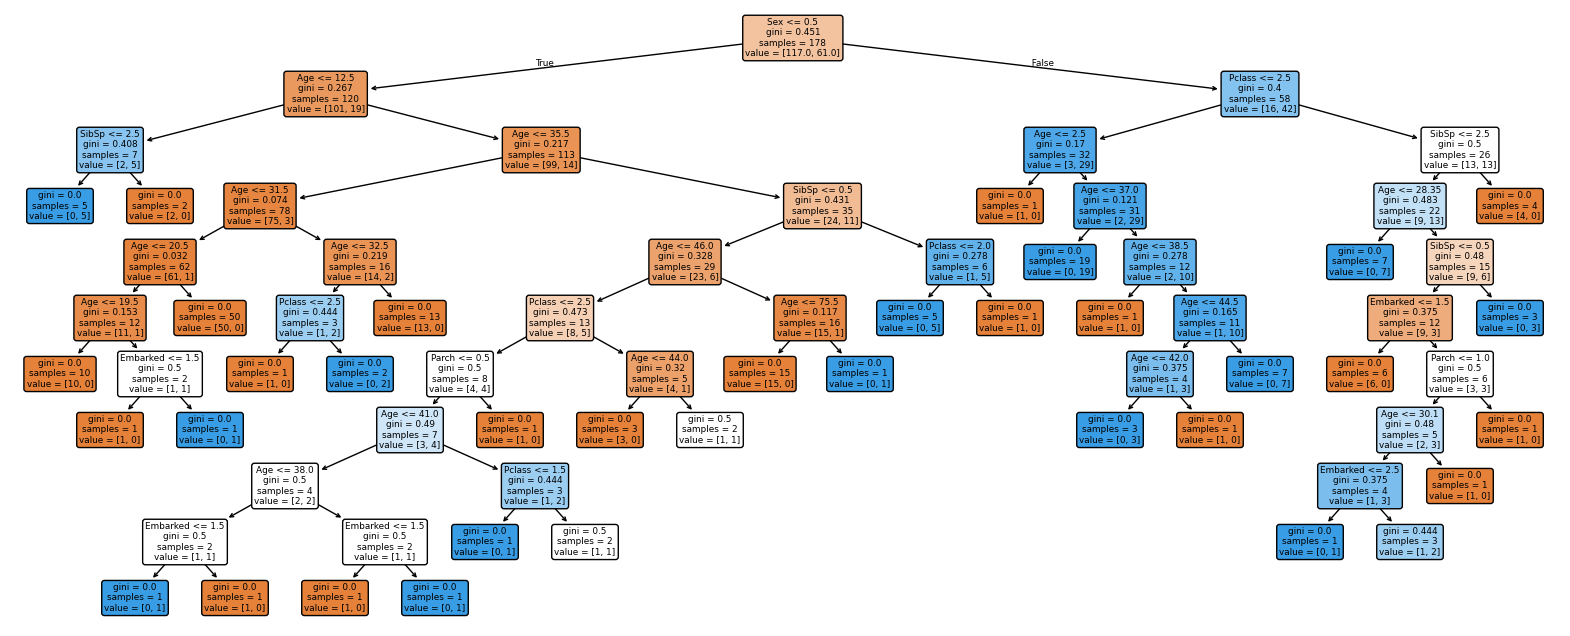

In [30]:
# Visualizamos el resultado del árbol de decisión
plt.figure(figsize=(20, 8))
plot_tree(clf, filled=True, feature_names=X.columns, rounded=True)
plt.show()

In [31]:
# Obtenemos la matriz de confusión y evaluamos la precisión del modelo
print(f'Matriz de confusión:')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Evaluamos la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.2f}')


Matriz de confusión:
[[350  82]
 [ 79 202]]
              precision    recall  f1-score   support

           0       0.82      0.81      0.81       432
           1       0.71      0.72      0.72       281

    accuracy                           0.77       713
   macro avg       0.76      0.76      0.76       713
weighted avg       0.77      0.77      0.77       713

Precisión del modelo: 0.77


In [32]:
#  Construimos el modelo para el clasificador de árbol de decisión modificando el hiperparámetro  max_depth=3
clf = DecisionTreeClassifier(max_depth=3)

# Entrenamos el modelo con los datos de entrenamiento
clf.fit(X_train, y_train)

# Probamos ese modelo que hemos entrenado en los datos de test y hacemos la predicción
y_pred = clf.predict(X_test)

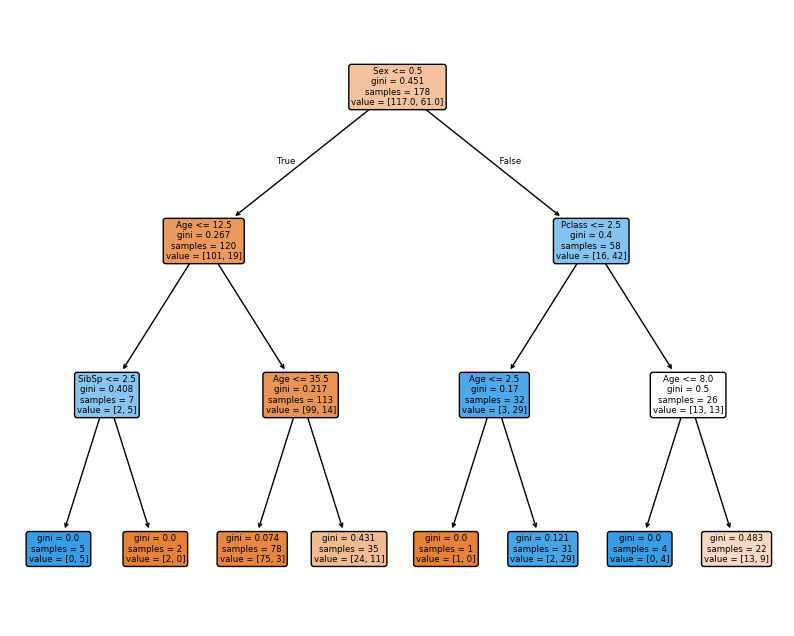

In [33]:
#  Visualizamos el resultado del árbol de decisión
plt.figure(figsize=(10, 8))
plot_tree(clf, filled=True, feature_names=X.columns, rounded=True)
plt.show()

In [34]:
# Obtenemos la matriz de confusión y evaluamos la precisión del modelo
print(f'Matriz de confusión:')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Evaluamos la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.2f}')


Matriz de confusión:
[[419  13]
 [128 153]]
              precision    recall  f1-score   support

           0       0.77      0.97      0.86       432
           1       0.92      0.54      0.68       281

    accuracy                           0.80       713
   macro avg       0.84      0.76      0.77       713
weighted avg       0.83      0.80      0.79       713

Precisión del modelo: 0.80


**12**. ¿Cómo interpretamos el resultado de esta matriz de confusión?

**Respuesta**
En la parte superior izquierda indica el número de VP, FP, FN y VN:

- 377 representa los TN = Pasajeros correctamente clasificados como no supervivientes (murieron).
- 55 representa los FP=Pasajeros incorrectamente clasificados como supervivientes (el modelo dijo que sobrevivieron pero murieron).
- 79 representa los FN= Pasajeros incorrectamente como que no han sobrevivido (el modelo dijo que murieron pero sobrevivieron).
- 202 representa los TP= Pasajeros correctamente clasificados como supervivientes (.

En el núcleo del matriz:
- La precisión para los que no sobrevivieron es de 0.83.
- La precisión para los que sobrevivieron es de 0.79.
- El recall para los que no sobrevivieron es de 0.87.
- El recall para los que sobrevivieron es de 0.72.

A la vista de estos resultados podemos estimar que el algoritmo predice mejor la clase 0, es decir, aquellos que no sobrevivieron.

La Accuracy del modelo es de 0.81, es decir, el modelo ha clasificado correctamente al 81% de los pasajeros. Estimamos que para resolver este problema, el modelo tiene un buen rendimiento.
